In [76]:
import torch
from torchvision import transforms
import pandas as pd
import matplotlib.pyplot as plt


import zipfile
from pathlib import Path
from PIL import Image
import shutil
from tqdm.auto import tqdm
import random
from collections import Counter

import ml_modules

## Device Agnostic code

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Data preparation

## Unzip data

In [14]:
# with zipfile.ZipFile('aptos2019-blindness-detection.zip', 'r') as zip_ref:

#     zip_ref.extractall('dataset/aptos2019')

## Load data

### Data dir

In [15]:
dataset_dir = Path('dataset/aptos2019')

train_dir = dataset_dir / 'train_images'
train_labels_file = dataset_dir / 'train.csv'

test_dir = dataset_dir / 'test_images'

### Create class folders and move data

In [16]:
images = list(train_dir.glob('*.png'))
images[:5]

[WindowsPath('dataset/aptos2019/train_images/000c1434d8d7.png'),
 WindowsPath('dataset/aptos2019/train_images/001639a390f0.png'),
 WindowsPath('dataset/aptos2019/train_images/0024cdab0c1e.png'),
 WindowsPath('dataset/aptos2019/train_images/002c21358ce6.png'),
 WindowsPath('dataset/aptos2019/train_images/005b95c28852.png')]

### Visualize image

(np.float64(-0.5), np.float64(818.5), np.float64(613.5), np.float64(-0.5))

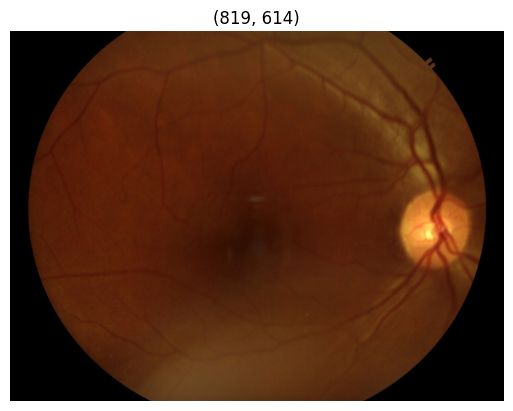

In [17]:
random_index = random.randint(0, len(images))
image = Image.open(images[random_index])
plt.title(label=image.size)
plt.imshow(image)
plt.axis(False)

### load labels

In [18]:
labels = pd.read_csv(train_labels_file)
labels.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


#### Split train data into train and validation set 

In [19]:
data_size = len(images)
train_size = (data_size*90//100)

train_images = images[:train_size]
validation_images = images[train_size:]

data_size, len(train_images), len(validation_images), train_images[:1], validation_images[:1]

(3662,
 3295,
 367,
 [WindowsPath('dataset/aptos2019/train_images/000c1434d8d7.png')],
 [WindowsPath('dataset/aptos2019/train_images/e4d3d437b0a8.png')])

#### Split labels

In [20]:
train_labels = labels[:train_size]
validation_labels = labels[train_size:]

len(train_labels), len(validation_labels), train_labels[:1], validation_labels[:1]

(3295,
 367,
         id_code  diagnosis
 0  000c1434d8d7          2,
            id_code  diagnosis
 3295  e4d3d437b0a8          0)

#### Saving train and validation images

In [21]:
def create_folders(dataset_dir: Path,
                   train_dir:bool,
                   test_dir:bool,
                   validatio_dir:bool,
                   classes: list[str] = ['']
                   ):

    train = Path('train')
    test = Path('test')
    validation = Path('validation')

    if train_dir:

        train = dataset_dir / train
        train.mkdir(parents=True, exist_ok=True)

    if test_dir:

        test = dataset_dir / test
        test.mkdir(parents=True, exist_ok=True)

    if validatio_dir:

        validation = dataset_dir / validation
        validation.mkdir(parents=True, exist_ok=True)


    for class_path in classes:


        if train_dir:

            train_class_path = train / class_path
            train_class_path.mkdir(exist_ok=True)

        if test_dir:

            test_class_path = test / class_path
            test_class_path.mkdir(exist_ok=True)

        if validatio_dir:

            validation_class_path = validation / class_path
            validation_class_path.mkdir(exist_ok=True)

    return train, test, validation

In [22]:
def copy_file(source_path, destination_path, file_name):

    try:

        shutil.copy2(source_path, destination_path / file_name)
    except:

        print(f"cannot copy {file_name} from {source_path} to {destination_path}")

In [23]:
## Create folders

classes = ['0', '1', '2', '3', '4']

train_dir, _, validation_dir = create_folders(dataset_dir=dataset_dir,
                                            train_dir=True,
                                            test_dir=False,
                                            validatio_dir=True,
                                            classes=classes)

print(f"[INFO] Folders created")

## For train images

print(f"[INFO] Saving training images")

for i in range(len(train_images)):

    train_image_path = train_images[i]
    train_image_name = train_image_path.parts[-1]

    train_label = str(train_labels['diagnosis'][i])

    copy_file(source_path=train_image_path,
              destination_path=train_dir / train_label,
              file_name=train_image_name)

print(f"[INFO] Train images saved at {train_dir}")


## For validation images

print(f"[INFO] Saving validation images")

for i in range(len(validation_images)):

    validation_image_path = validation_images[i]
    validation_image_name = validation_image_path.parts[-1]

    validation_label = str(list(validation_labels['diagnosis'])[i])

    copy_file(source_path=validation_image_path,
              destination_path=validation_dir / validation_label,
              file_name=validation_image_name)

print(f"[INFO] Validation images saved at {validation_dir}")

[INFO] Folders created
[INFO] Saving training images
[INFO] Train images saved at dataset\aptos2019\train
[INFO] Saving validation images
[INFO] Validation images saved at dataset\aptos2019\validation


### Create dataloaders

In [63]:
manual_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor()
])

BATCH_SIZE = 32
NUM_WORKERS = 0
 
train_dataloader, vlaidation_dataloader, classes =  ml_modules.get_dataloaders(train_dir=train_dir,
                                                                         test_dir=validation_dir,
                                                                         BATCH_SIZE=BATCH_SIZE,
                                                                         NUM_WORKERS=NUM_WORKERS,
                                                                         train_transform=manual_transform,
                                                                         test_transform=manual_transform)

In [61]:
classes

['0', '1', '2', '3', '4']

In [38]:
images = train_dataloader

In [39]:
len(images) * 32

3296

## Visualize image from dataloader

In [64]:
images, labels = next(iter(train_dataloader))
images = images[:10]
labels = labels[:10]

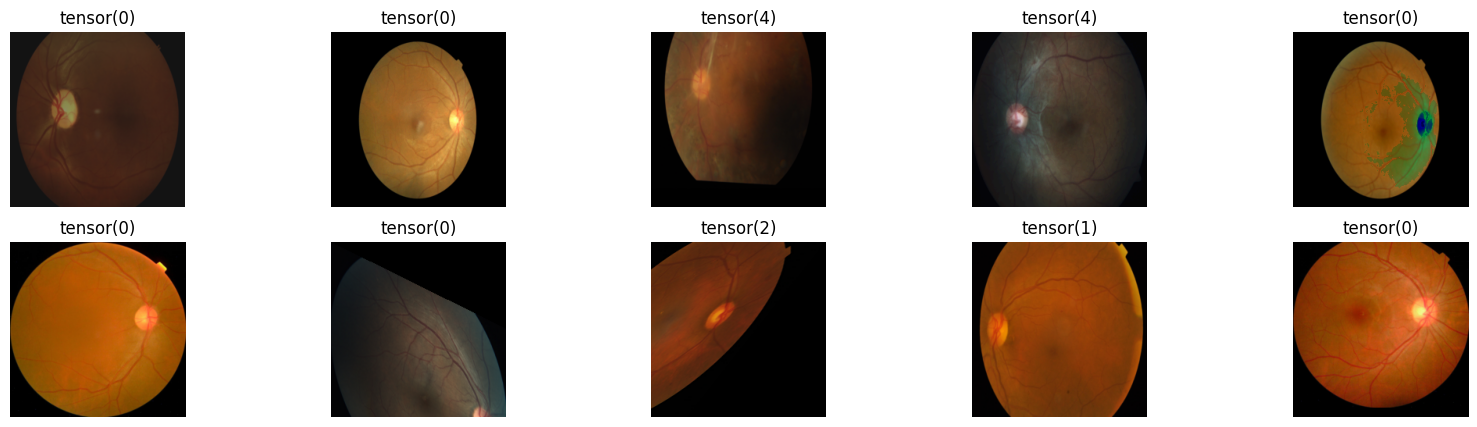

In [68]:
fig = plt.figure(figsize=(20, 5))
fig.subplots(2, 5)

for i, (image) in enumerate(images):

    plt.subplot(2, 5, i + 1)
    plt.title(label=labels[i])
    plt.imshow(image.permute(1, 2, 0))
    plt.axis(False)

## Count classes and their data

In [88]:
Counter(list(train_dataloader.dataset.targets))

Counter({0: 1605, 2: 912, 1: 340, 4: 262, 3: 176})